### Ensemble Learning Guide to Random Forest and XGBoost

## What Is Ensemble Learning?
Ensemble learning trains multiple models and combines their predictions into a single output. The idea is simple: different models make different mistakes, so averaging or voting across many models tends to cancel out individual errors.

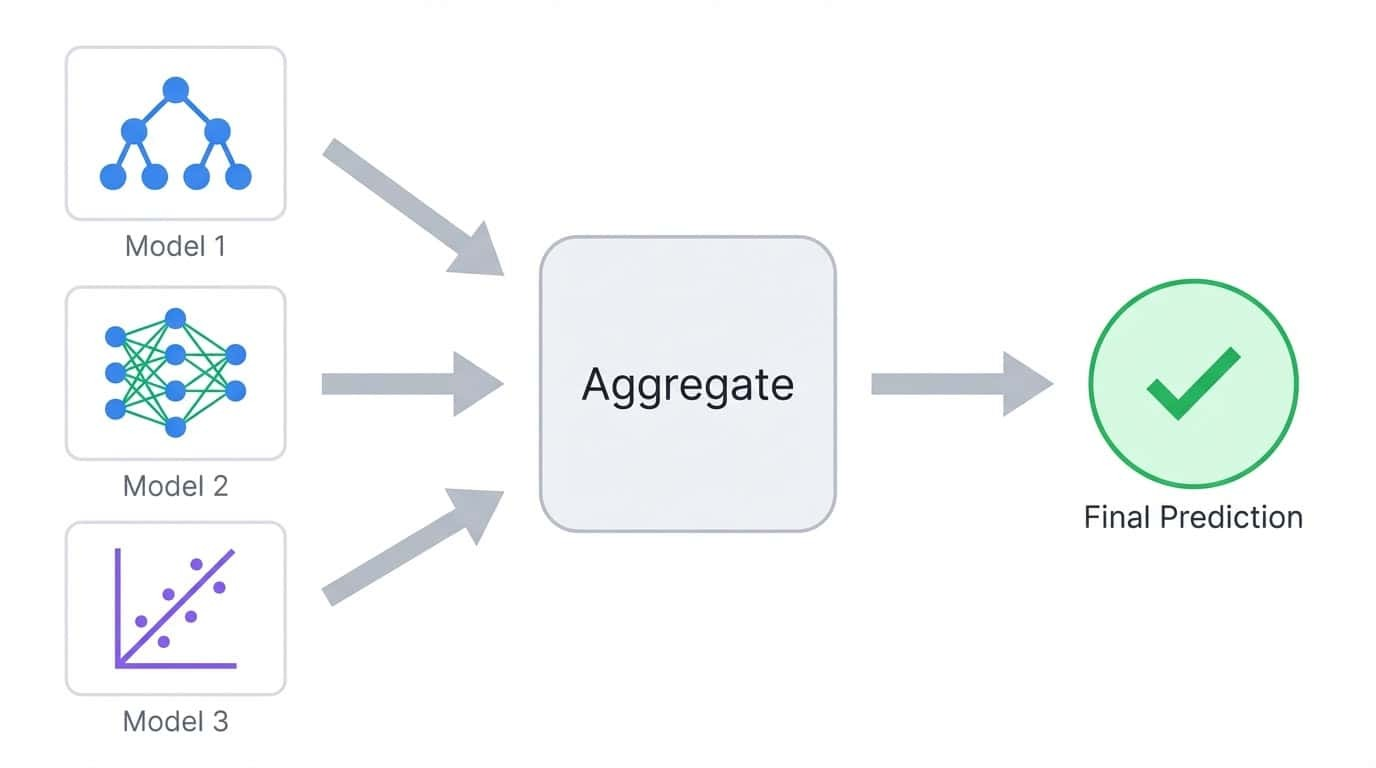

### The bias-variance trade-off
Model errors come from two sources: bias and variance.

### Bias is the error
 from oversimplifying the problem. A linear model trying to fit a curved relationship has high bias because it can't represent the true pattern, no matter how much data you give it. High-bias models produce similar predictions across different training sets, but those predictions are always off-target.

### Variance is the error 
from being too sensitive to training data. A deep decision tree that memorizes the training set has high variance because it captures noise along with signal. If you retrained the same tree on a slightly different sample, you'd get wildly different predictions. The model fits the training data well, but falls apart on anything new.

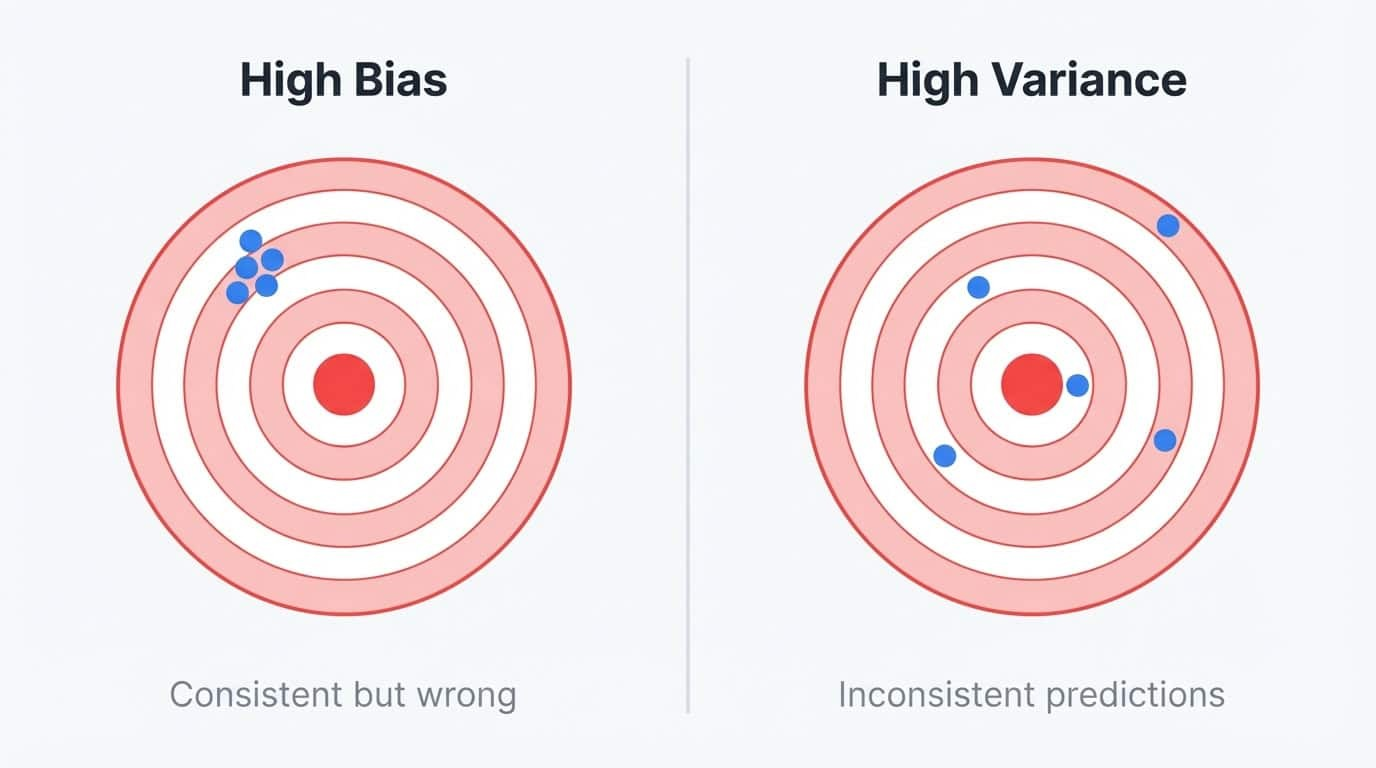

### Ensemble methods break this trade-off by combining multiple models:

### Bagging 
Bagging trains many models in parallel on random subsets of data, then averages their predictions. This reduces variance by smoothing out the quirks of individual models. The intuition is straightforward: if each model makes somewhat independent errors, averaging tends to cancel those errors out. The more models you combine, the more stable the final prediction becomes. This is why Random Forest defaults to 100 trees rather than 10.

### Boosting 
Boosting trains models sequentially, where each new model focuses on the mistakes of the previous ones. This reduces bias by building a strong learner from many weak ones.

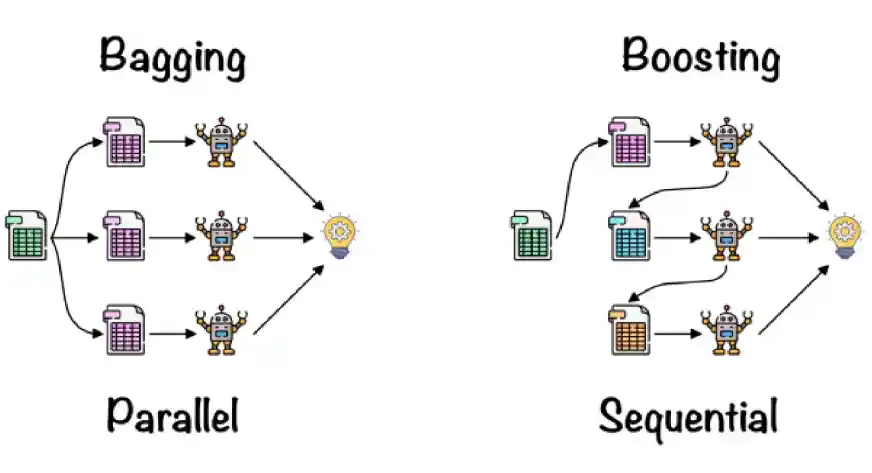

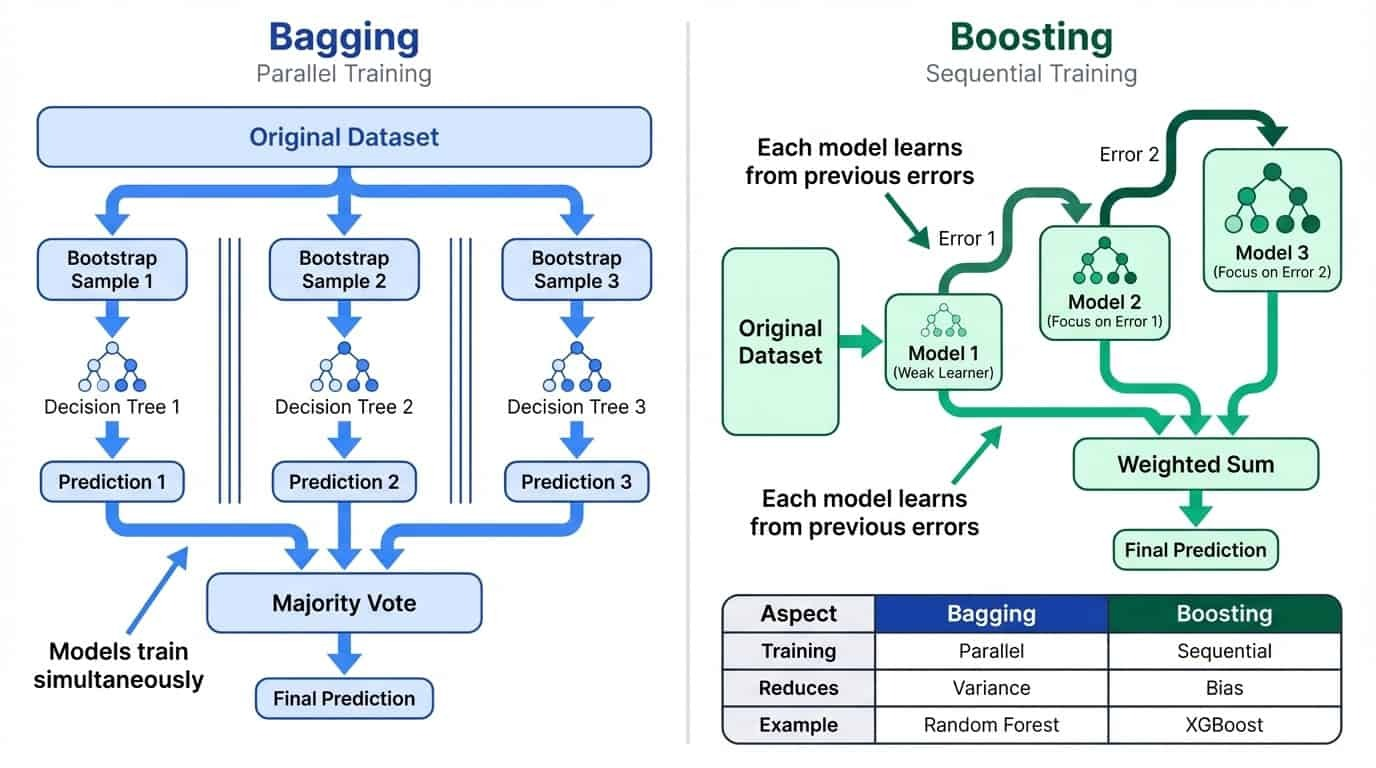

In [52]:
!pip install ucimlrepo

### Dataset link and info 
https://archive.ics.uci.edu/dataset/602/dry+bean+dataset
Researchers Koklu and Ozkan (2020) photographed 13,611 dry beans from seven varieties and extracted 16 geometric features from each image, including area, perimeter, axis lengths, and shape factors. The task is to classify each bean by variety based on these measurements.

The dataset works well for this tutorial because it's a clean multiclass problem with all numeric features. No missing values, no categorical encoding, no text preprocessing. You can focus entirely on the ensemble methods.

In [53]:

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
import pandas as pd

dry_bean = fetch_ucirepo(id=602)
X = dry_bean.data.features
y = dry_bean.data.targets.values.ravel()

print(f"Features shape: {X.shape}")
print(f"Target classes: {pd.Series(y).nunique()}")

Features shape: (13611, 16)
Target classes: 7


In [54]:
X.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166


In [55]:
pd.Series(y).value_counts()

DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
 	X, y, test_size=0.2, random_state=42, stratify=y
 )
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 10888 samples
Test set: 2723 samples


In [57]:
y_train

array(['SEKER', 'HOROZ', 'CALI', ..., 'BARBUNYA', 'HOROZ', 'BOMBAY'],
      shape=(10888,), dtype=object)

In [58]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9218
              precision    recall  f1-score   support

    BARBUNYA       0.94      0.89      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.94      0.94      0.94       326
    DERMASON       0.91      0.92      0.91       709
       HOROZ       0.96      0.95      0.96       386
       SEKER       0.94      0.96      0.95       406
        SIRA       0.86      0.86      0.86       527

    accuracy                           0.92      2723
   macro avg       0.94      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



This code creates a forest of 100 decision trees, trains them on the bootstrap samples, and generates predictions by majority vote. The random_state parameter fixes the random seed so results are reproducible.

The classification report breaks down performance by class. Precision measures how many predicted positives were correct, recall measures how many actual positives were found, and F1-score is their harmonic mean. Bombay beans are classified perfectly (likely because they're physically distinct), while Sira beans are the hardest to distinguish from other varieties.

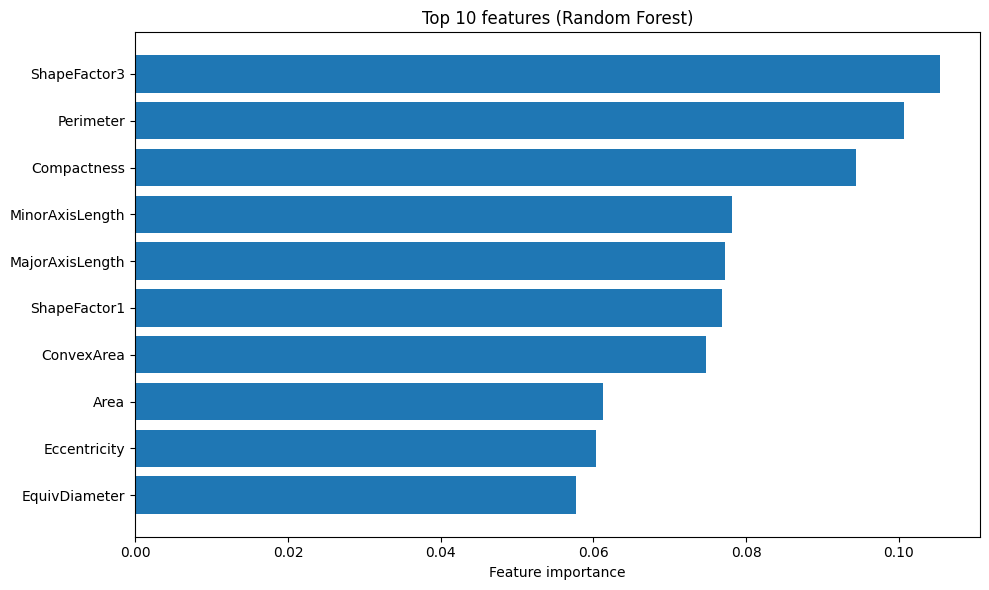

In [59]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_
feature_names = X.columns
sorted_idx = importances.argsort()[::-1][:10]

plt.figure(figsize=(10, 6))
plt.barh(range(10), importances[sorted_idx][::-1])
plt.yticks(range(10), feature_names[sorted_idx][::-1])
plt.xlabel("Feature importance")
plt.title("Top 10 features (Random Forest)")
plt.tight_layout()
plt.show()

### Hyperparameters worth tuning


In [60]:
from sklearn.model_selection import GridSearchCV

param_grid = {
 	"n_estimators": [100, 200],
 	"max_depth": [10, 20, None],
 	"max_features": ["sqrt", "log2"]
 }

grid_search = GridSearchCV(
     RandomForestClassifier(random_state=42),
 	param_grid,
 	cv=3,
 	scoring="accuracy",
 	n_jobs=-1
 )
grid_search.fit(X_train, y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")

Best params: {'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 200}
Best CV accuracy: 0.9245


In [61]:
y_pred_tuned = grid_search.best_estimator_.predict(X_test)
print(f"Tuned test accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")

Tuned test accuracy: 0.9199


### XGBoost Classifier 

In [62]:
!pip install xgboost

In [63]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric="mlogloss")
xgb.fit(X_train, y_train_encoded)
y_pred_xgb = xgb.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test_encoded, y_pred_xgb):.4f}")
print(classification_report(y_test_encoded, y_pred_xgb, target_names=le.classes_))

Accuracy: 0.9232
              precision    recall  f1-score   support

    BARBUNYA       0.94      0.91      0.93       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.95      0.94      0.94       326
    DERMASON       0.90      0.92      0.91       709
       HOROZ       0.97      0.96      0.96       386
       SEKER       0.94      0.96      0.95       406
        SIRA       0.87      0.86      0.86       527

    accuracy                           0.92      2723
   macro avg       0.94      0.93      0.94      2723
weighted avg       0.92      0.92      0.92      2723



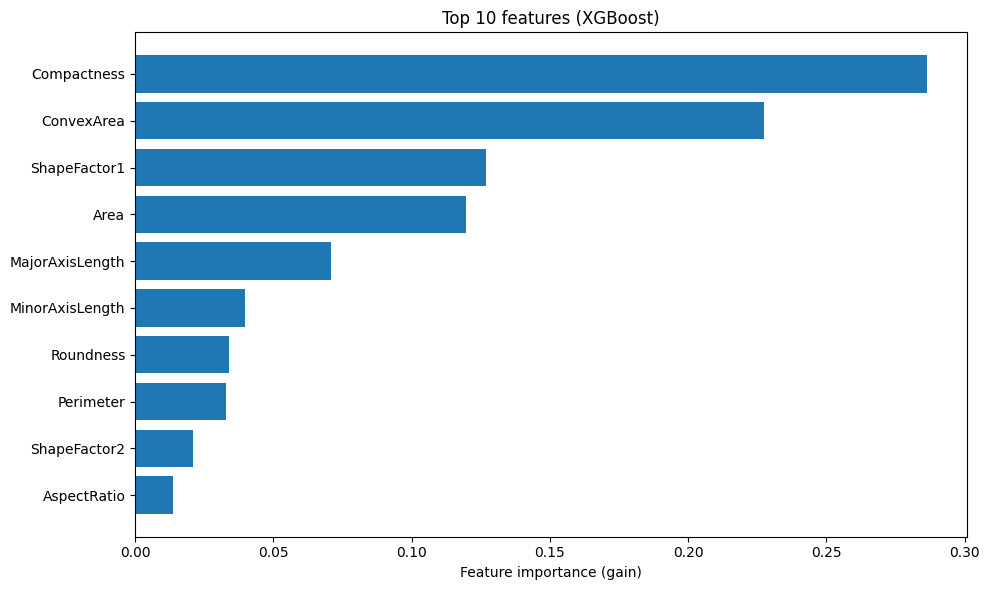

In [64]:
importances_xgb = xgb.feature_importances_
sorted_idx_xgb = importances_xgb.argsort()[::-1][:10]

plt.figure(figsize=(10, 6))
plt.barh(range(10), importances_xgb[sorted_idx_xgb][::-1])
plt.yticks(range(10), feature_names[sorted_idx_xgb][::-1])
plt.xlabel("Feature importance (gain)")
plt.title("Top 10 features (XGBoost)")
plt.tight_layout()
plt.show()

## Hyperparameters worth tuning


In [65]:
param_grid_xgb = {
 	"learning_rate": [0.05, 0.1],
 	"max_depth": [4, 6],
 	"n_estimators": [100, 200],
 	"reg_lambda": [1, 5]
 }

grid_search_xgb = GridSearchCV(
 	XGBClassifier(random_state=42, eval_metric="mlogloss"),
 	param_grid_xgb,
 	cv=3,
 	scoring="accuracy",
 	n_jobs=-1
 )
grid_search_xgb.fit(X_train, y_train_encoded)

print(f"Best params: {grid_search_xgb.best_params_}")
print(f"Best CV accuracy: {grid_search_xgb.best_score_:.4f}")

Best params: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'reg_lambda': 1}
Best CV accuracy: 0.9279


In [66]:
y_pred_xgb_tuned = grid_search_xgb.best_estimator_.predict(X_test)
print(f"Tuned test accuracy: {accuracy_score(y_test_encoded, y_pred_xgb_tuned):.4f}")

Tuned test accuracy: 0.9243


### using iris dataset

In [67]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load dataset
data = load_iris()
X, y = data.data, data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Base model
base_model = DecisionTreeClassifier()

# Bagging model
bagging_model = BaggingClassifier(
    estimator=base_model,
    n_estimators=10,   # number of trees
    random_state=42
)

# Train
bagging_model.fit(X_train, y_train)

# Predict
y_pred = bagging_model.predict(X_test)

# Accuracy
print("Bagging Accuracy:", accuracy_score(y_test, y_pred))

Bagging Accuracy: 0.9666666666666667


In [68]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# Base model (weak learner)
base_model = DecisionTreeClassifier(max_depth=1)

# AdaBoost model
boost_model = AdaBoostClassifier(
    estimator=base_model,
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

# Train
boost_model.fit(X_train, y_train)

# Predict
y_pred = boost_model.predict(X_test)

print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred))

AdaBoost Accuracy: 0.9666666666666667


In [69]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred = gb_model.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred))

Gradient Boosting Accuracy: 0.9666666666666667


In [70]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

# Load data
X, y = load_iris(return_X_y=True)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Create pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),   # Step 1: Preprocessing
    ('model', RandomForestClassifier())  # Step 2: Model
])

# Train pipeline
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


In [71]:
# Predict directly (no need to scale manually)
y_pred = pipeline.predict(X_test)

print(y_pred)

[1 2 2 0 0 2 1 2 1 1 1 0 0 0 2 0 0 1 1 1 2 0 2 0 2 0 0 2 0 1]


In [72]:
pipeline.predict(X_test)

array([1, 2, 2, 0, 0, 2, 1, 2, 1, 1, 1, 0, 0, 0, 2, 0, 0, 1, 1, 1, 2, 0,
       2, 0, 2, 0, 0, 2, 0, 1])